# PneumoScan — Détection de pneumonie (RSNA) avec YOLO11m — v4

**Changements par rapport à la v3 (mAP@0.5 = 0,367 à l'epoch 61, coupée par la limite 12h de Kaggle) :**
1. **CLAHE** (égalisation de contraste adaptative) ajouté à la conversion — fait ressortir les tissus flous, technique standard en imagerie médicale
2. `RATIO_NEGATIFS` : 2.0 → **1.5** — compromis entre la v2 (1.0) et la v3 (2.0)
3. `box=8.5` (au lieu de 7.5) — renforce la précision de localisation
4. `mosaic=0.3` (au lieu de 0.6), `close_mosaic=15` — réduit la déformation anatomique de cette augmentation
5. **`save_period=5`** — sauvegarde un checkpoint versionné toutes les 5 epochs, en plus de `last.pt`
6. **`epochs=60`** (pas 100, pas 896px) — dimensionné pour rester sous la limite de 12h de Kaggle, avec marge

⚠️ **`imgsz` reste à 640, pas 896** — une résolution plus grande risquerait un `CUDA out of memory` sur le Tesla T4 (14,9 Go de VRAM) et dépasserait presque certainement la limite de 12h, comme on l'a déjà vécu.

⚠️ Vérifie **Settings → Accelerator → GPU T4 x2** avant de lancer. Utilise « Save Version → Save & Run All (Commit) ».

In [1]:
!pip install -q ultralytics pydicom opencv-python-headless

import os, random
import numpy as np
import pandas as pd
import pydicom
import cv2
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
import torch

print("GPU disponible :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Appareil :", torch.cuda.get_device_name(0))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 3.9 MB/s eta 0:00:00
GPU disponible : True
Appareil : Tesla T4


## 1. Configuration et chargement des annotations

In [2]:
RSNA = '/kaggle/input/competitions/rsna-pneumonia-detection-challenge'
WORK = '/kaggle/working/dataset'
RUN_NAME = 'pneumoscan_yolo11m_v4'
RUN_DIR = f'/kaggle/working/pneumoscan_runs/{RUN_NAME}'

TAILLE_PNG = 640        # v4 : reste a 640 (pas 896) pour eviter OOM et timeout Kaggle
RATIO_NEGATIFS = 1.5    # v4 : etait 2.0 en v3, 1.0 en v2
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

labels = pd.read_csv(f'{RSNA}/stage_2_train_labels.csv')
print("Lignes :", len(labels))
print("Patients uniques :", labels['patientId'].nunique())
labels.head()


Lignes : 30227
Patients uniques : 26684


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


## 2. Sélection du dataset (ratio négatifs ajusté)

In [3]:
boites = {}
for r in labels.itertuples(index=False):
    d = boites.setdefault(r.patientId, [])
    if r.Target == 1 and not pd.isna(r.x):
        d.append([r.x, r.y, r.width, r.height])

positifs = [p for p, b in boites.items() if len(b) > 0]
negatifs = [p for p, b in boites.items() if len(b) == 0]
negatifs_retenus = random.sample(negatifs, min(len(negatifs), int(len(positifs) * RATIO_NEGATIFS)))

ids = positifs + negatifs_retenus
cible = [1] * len(positifs) + [0] * len(negatifs_retenus)
print(f"Positifs : {len(positifs)} | Negatifs retenus : {len(negatifs_retenus)} | Total : {len(ids)}")

from sklearn.model_selection import train_test_split
train_ids, val_ids = train_test_split(ids, test_size=0.2, random_state=SEED, stratify=cible)
print(f"Train : {len(train_ids)} | Val : {len(val_ids)}")


Positifs : 6012 | Negatifs retenus : 9018 | Total : 15030
Train : 12024 | Val : 3006


## 3. Conversion DICOM → PNG avec CLAHE + labels YOLO

CLAHE (Contrast Limited Adaptive Histogram Equalization) egalise le contraste localement, ce qui fait ressortir les textures pulmonaires floues — deja mentionne dans le pretraitement prevu au debut du projet.

In [4]:
for split in ['train', 'val']:
    os.makedirs(f'{WORK}/images/{split}', exist_ok=True)
    os.makedirs(f'{WORK}/labels/{split}', exist_ok=True)

def convertir_avec_clahe(pid, split):
    ds = pydicom.dcmread(f'{RSNA}/stage_2_train_images/{pid}.dcm')
    img = ds.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-6) * 255.0
    img = img.astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    h, w = img.shape
    im = Image.fromarray(img)
    if TAILLE_PNG:
        im = im.resize((TAILLE_PNG, TAILLE_PNG), Image.BILINEAR)
    im.save(f'{WORK}/images/{split}/{pid}.png')

    lignes = []
    for x, y, bw, bh in boites[pid]:
        cx, cy = (x + bw / 2) / w, (y + bh / 2) / h
        nw, nh = bw / w, bh / h
        lignes.append(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")
    with open(f'{WORK}/labels/{split}/{pid}.txt', 'w') as f:
        f.write('\n'.join(lignes))

for split, liste in [('train', train_ids), ('val', val_ids)]:
    with ThreadPoolExecutor(max_workers=8) as ex:
        list(tqdm(ex.map(lambda p: convertir_avec_clahe(p, split), liste), total=len(liste), desc=f"Conversion {split}"))

print("Images train :", len(os.listdir(f'{WORK}/images/train')))
print("Images val   :", len(os.listdir(f'{WORK}/images/val')))


Conversion train:   0%|          | 0/12024 [00:00<?, ?it/s]

Conversion val:   0%|          | 0/3006 [00:00<?, ?it/s]

Images train : 12024
Images val   : 3006


In [5]:
data_yaml = f"""path: {WORK}
train: images/train
val: images/val
nc: 1
names:
  0: pneumonie
"""
with open(f'{WORK}/data.yaml', 'w') as f:
    f.write(data_yaml)
print(data_yaml)


path: /kaggle/working/dataset
train: images/train
val: images/val
nc: 1
names:
  0: pneumonie



## 4. Vérification visuelle (avant/après CLAHE, à mettre dans la présentation)

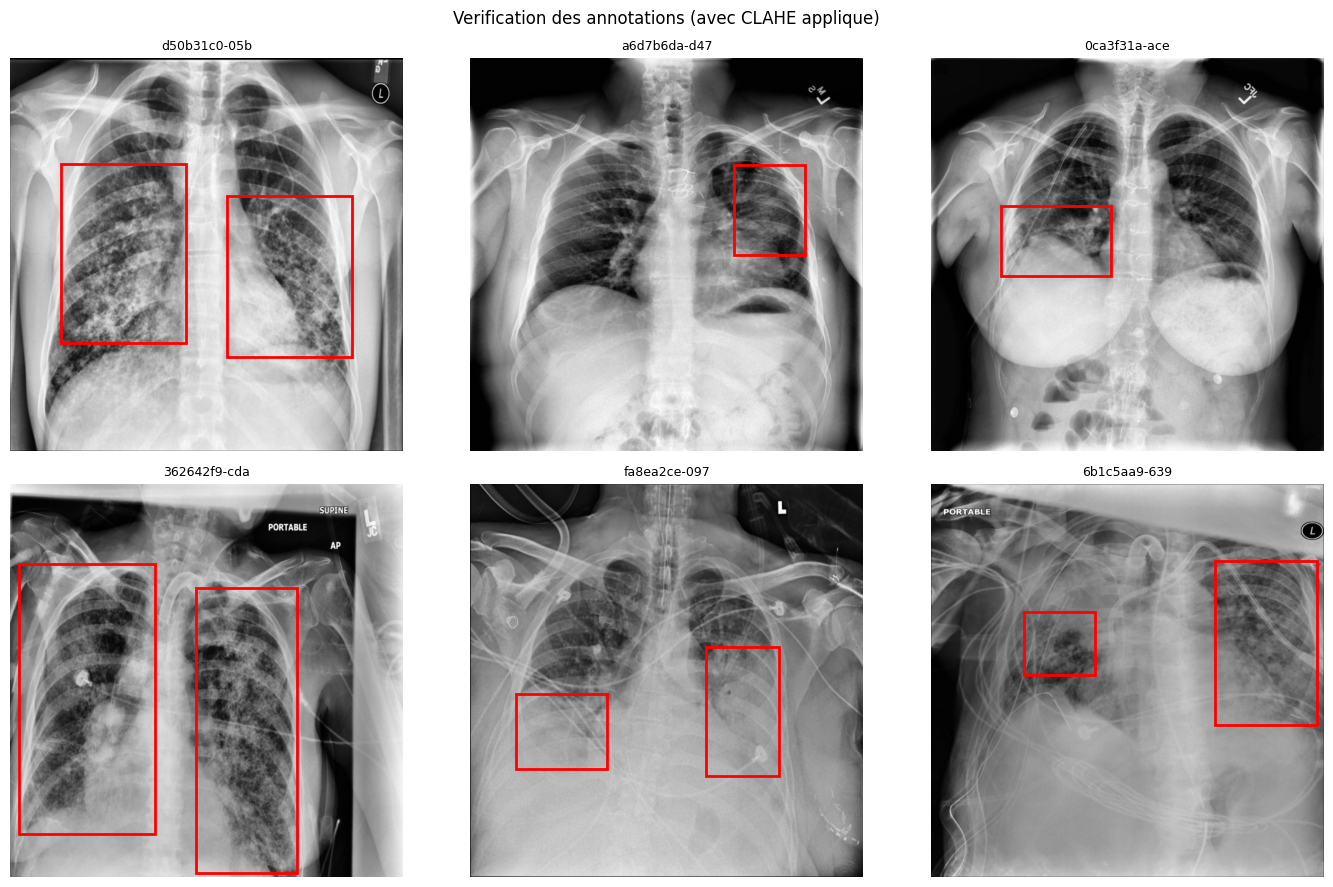

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

exemples = [p for p in train_ids if len(boites[p]) > 0][:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, pid in zip(axes.ravel(), exemples):
    im = Image.open(f'{WORK}/images/train/{pid}.png')
    ax.imshow(im, cmap='gray')
    for ligne in open(f'{WORK}/labels/train/{pid}.txt').read().splitlines():
        _, cx, cy, nw, nh = map(float, ligne.split())
        W, H = im.size
        ax.add_patch(patches.Rectangle(((cx - nw/2)*W, (cy - nh/2)*H), nw*W, nh*H,
                                       fill=False, edgecolor='red', linewidth=2))
    ax.set_title(pid[:12], fontsize=9); ax.axis('off')
plt.suptitle("Verification des annotations (avec CLAHE applique)")
plt.tight_layout(); plt.show()


## 5. Entraînement (v4)

`epochs=60`, `save_period=5` (checkpoint versionne toutes les 5 epochs, en plus de `last.pt` a chaque epoch) — dimensionne pour rester sous la limite de 12h de Kaggle avec de la marge.

In [7]:
from ultralytics import YOLO

model = YOLO('yolo11m.pt')

resultats = model.train(
    data=f'{WORK}/data.yaml',
    epochs=60,                  # v4 : dimensionne pour tenir dans les 12h Kaggle
    imgsz=TAILLE_PNG,           # 640, pas 896
    batch=16,
    save_period=5,              # v4 : checkpoint versionne toutes les 5 epochs
    project='/kaggle/working/pneumoscan_runs',
    name=RUN_NAME,
    exist_ok=True,
    seed=SEED,

    # optimisation
    optimizer='AdamW',
    lr0=0.0015, lrf=0.01, cos_lr=True,
    warmup_epochs=3.0, weight_decay=0.0005,
    patience=12,

    # ponderation des pertes (localisation renforcee)
    box=8.5, cls=0.5, dfl=1.5,

    # augmentation adaptee aux radios
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.4,
    degrees=5.0, translate=0.08, scale=0.2,
    shear=0.0, perspective=0.0,
    fliplr=0.5, flipud=0.0,
    mosaic=0.3, close_mosaic=15, mixup=0.0, erasing=0.1,

    single_cls=True, amp=True, plots=True, workers=4, cache=False,
)


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.127 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=8.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=5.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.1, exist_ok=True, fliplr=0.5, flipud=0.0, 

## 6. Évaluation — les chiffres à présenter

In [8]:
best = YOLO(f'{RUN_DIR}/weights/best.pt')

m = best.val(data=f'{WORK}/data.yaml', imgsz=TAILLE_PNG, split='val', plots=True)

tableau = pd.DataFrame([{
    'Precision (P)': round(m.box.mp, 4),
    'Rappel (R)':    round(m.box.mr, 4),
    'mAP@0.5':       round(m.box.map50, 4),
    'mAP@0.5:0.95':  round(m.box.map, 4),
    'F1':            round(2 * m.box.mp * m.box.mr / (m.box.mp + m.box.mr + 1e-9), 4),
}])
display(tableau)
tableau.to_csv('/kaggle/working/metriques_finales_v4.csv', index=False)


Ultralytics 8.4.127 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11m summary (fused): 126 layers, 20,030,803 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3075.0±1020.4 MB/s, size: 182.6 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 3006 images, 1804 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3006/3006 1.1Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 188/188 1.8it/s 1:43
                   all       3006       1912      0.405       0.45      0.407      0.163
Speed: 0.9ms preprocess, 31.3ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/runs/detect/val


,Precision (P),Rappel (R),mAP@0.5,mAP@0.5:0.95,F1
0,0.4051,0.4498,0.4074,0.1632,0.4263


In [9]:
lignes = []
for conf in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    r = best.val(data=f'{WORK}/data.yaml', imgsz=TAILLE_PNG, conf=conf, plots=False, verbose=False)
    p, rec = r.box.mp, r.box.mr
    f1 = 2 * p * rec / (p + rec + 1e-9)
    lignes.append({'conf': conf, 'Precision': round(p, 4), 'Rappel': round(rec, 4),
                   'F1': round(f1, 4), 'mAP@0.5': round(r.box.map50, 4)})

sweep = pd.DataFrame(lignes)
display(sweep)
meilleur = sweep.loc[sweep['F1'].idxmax()]
print(f"\nMeilleur compromis : conf={meilleur['conf']} -> P={meilleur['Precision']}, R={meilleur['Rappel']}, F1={meilleur['F1']}")
sweep.to_csv('/kaggle/working/balayage_seuil_v4.csv', index=False)


Ultralytics 8.4.127 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3229.1±1176.4 MB/s, size: 174.9 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 3006 images, 1804 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3006/3006 1.3Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 188/188 1.9it/s 1:42
                   all       3006       1912      0.405       0.45      0.345      0.134
Speed: 0.8ms preprocess, 31.6ms inference, 0.0ms loss, 0.4ms postprocess per image
Ultralytics 8.4.127 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2365.1±726.1 MB/s, size: 180.7 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 3006 images, 1804 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3006/3006 1.6Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP5

,conf,Precision,Rappel,F1,mAP@0.5
0,0.10,0.4051,0.4498,0.4263,0.3447
1,0.15,0.3816,0.4786,0.4246,0.2963
2,0.20,0.4789,0.3797,0.4236,0.2530
3,0.25,0.5672,0.2934,0.3868,0.2111
4,0.30,0.6461,0.2082,0.3149,0.1558
5,0.40,0.7551,0.0387,0.0736,0.0285
6,0.50,0.0000,0.0000,0.0000,0.0000



Meilleur compromis : conf=0.1 -> P=0.4051, R=0.4498, F1=0.4263


— results.png


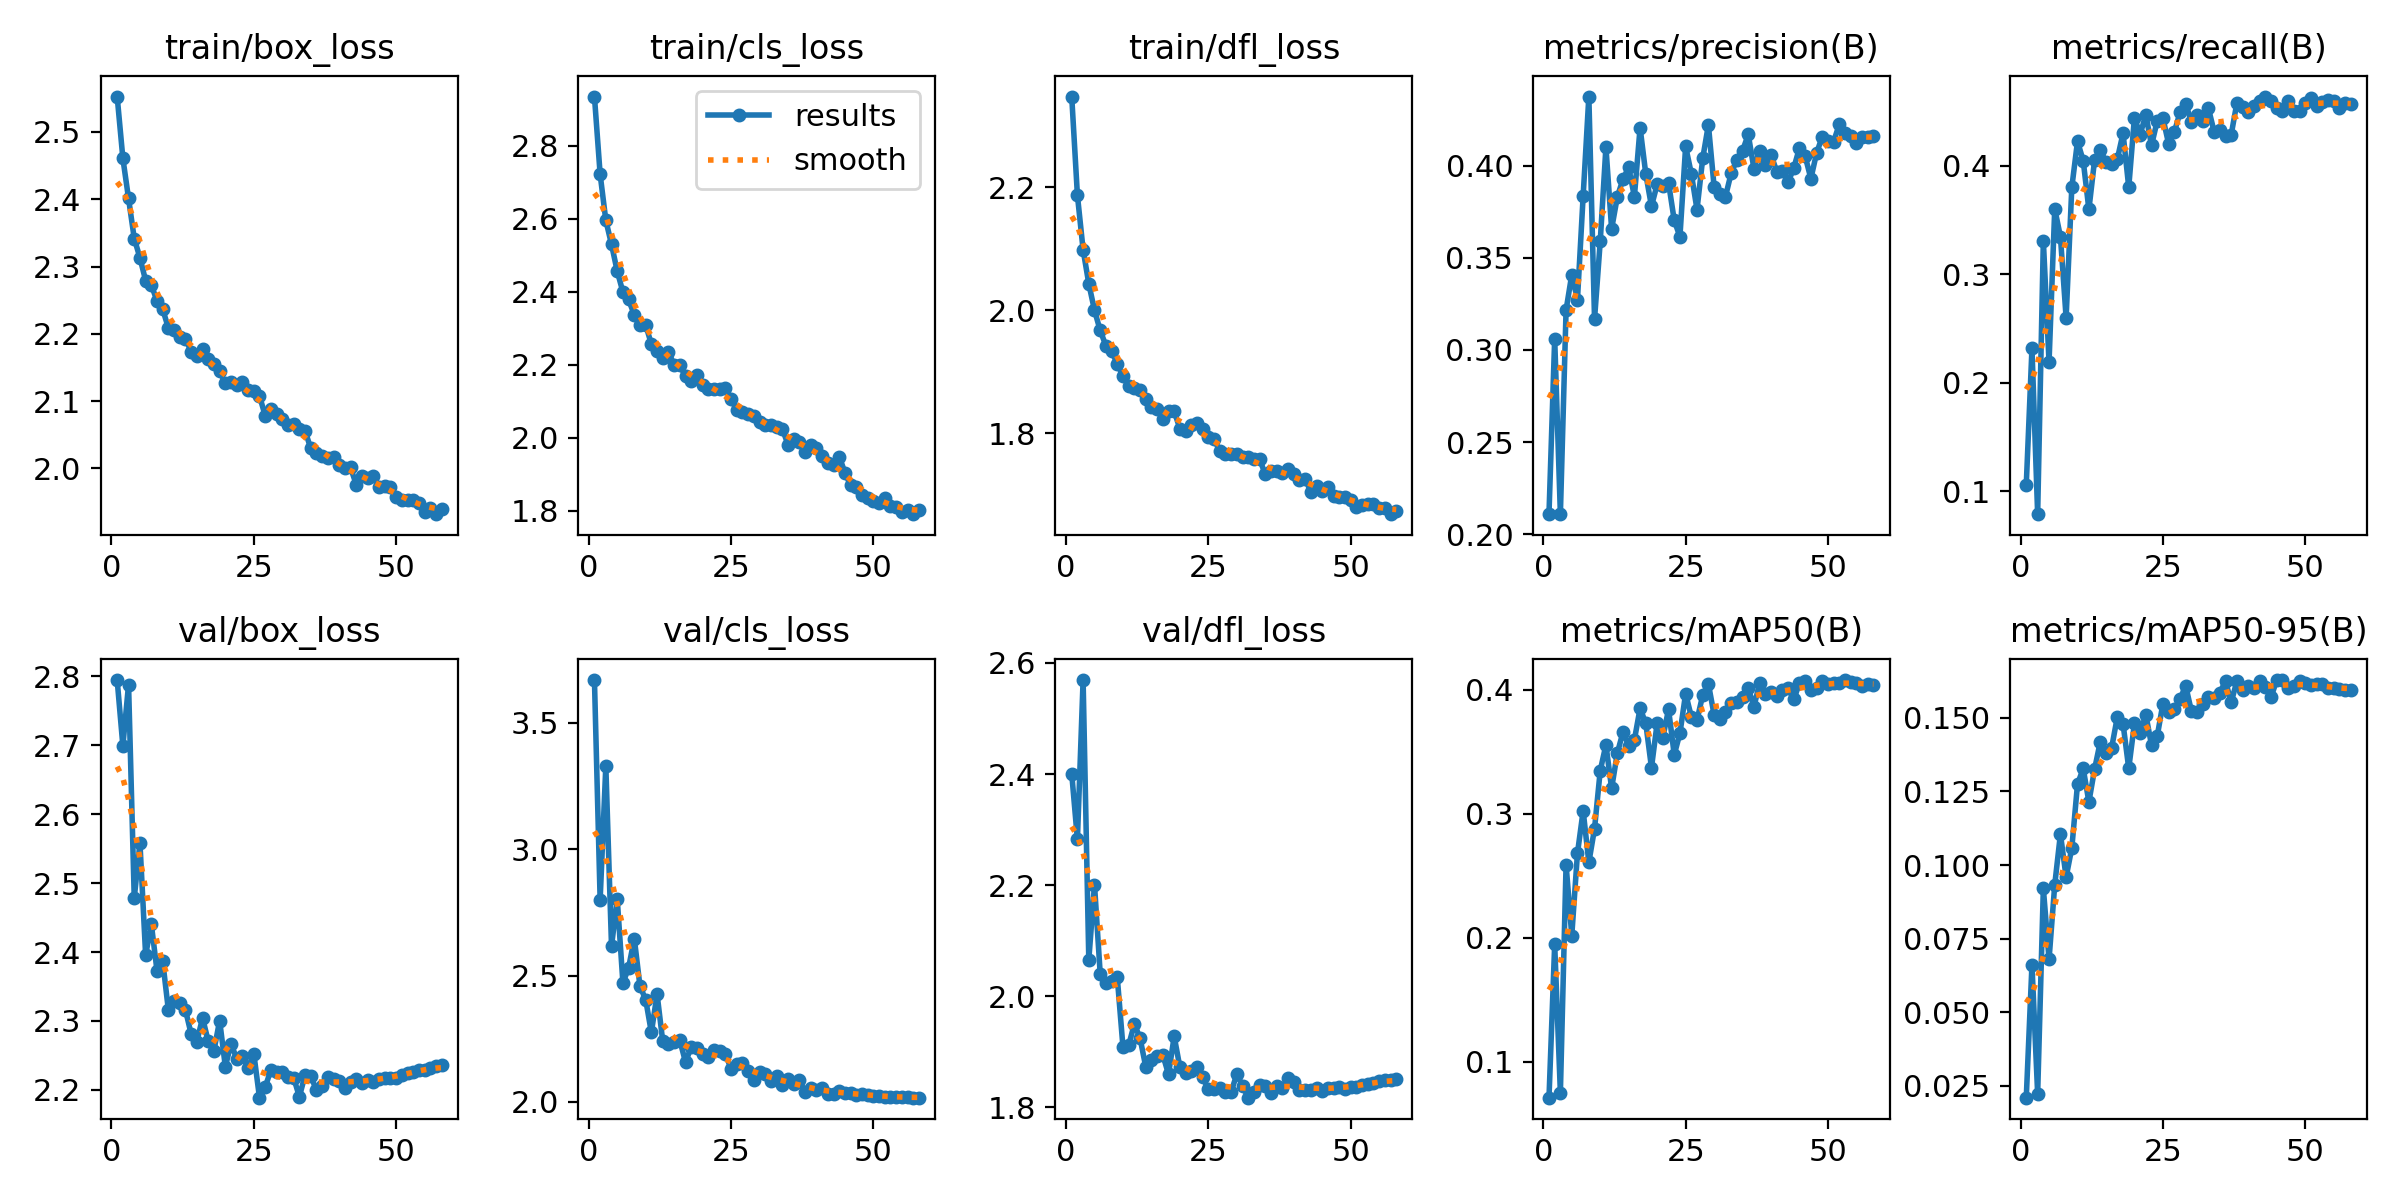

— confusion_matrix_normalized.png


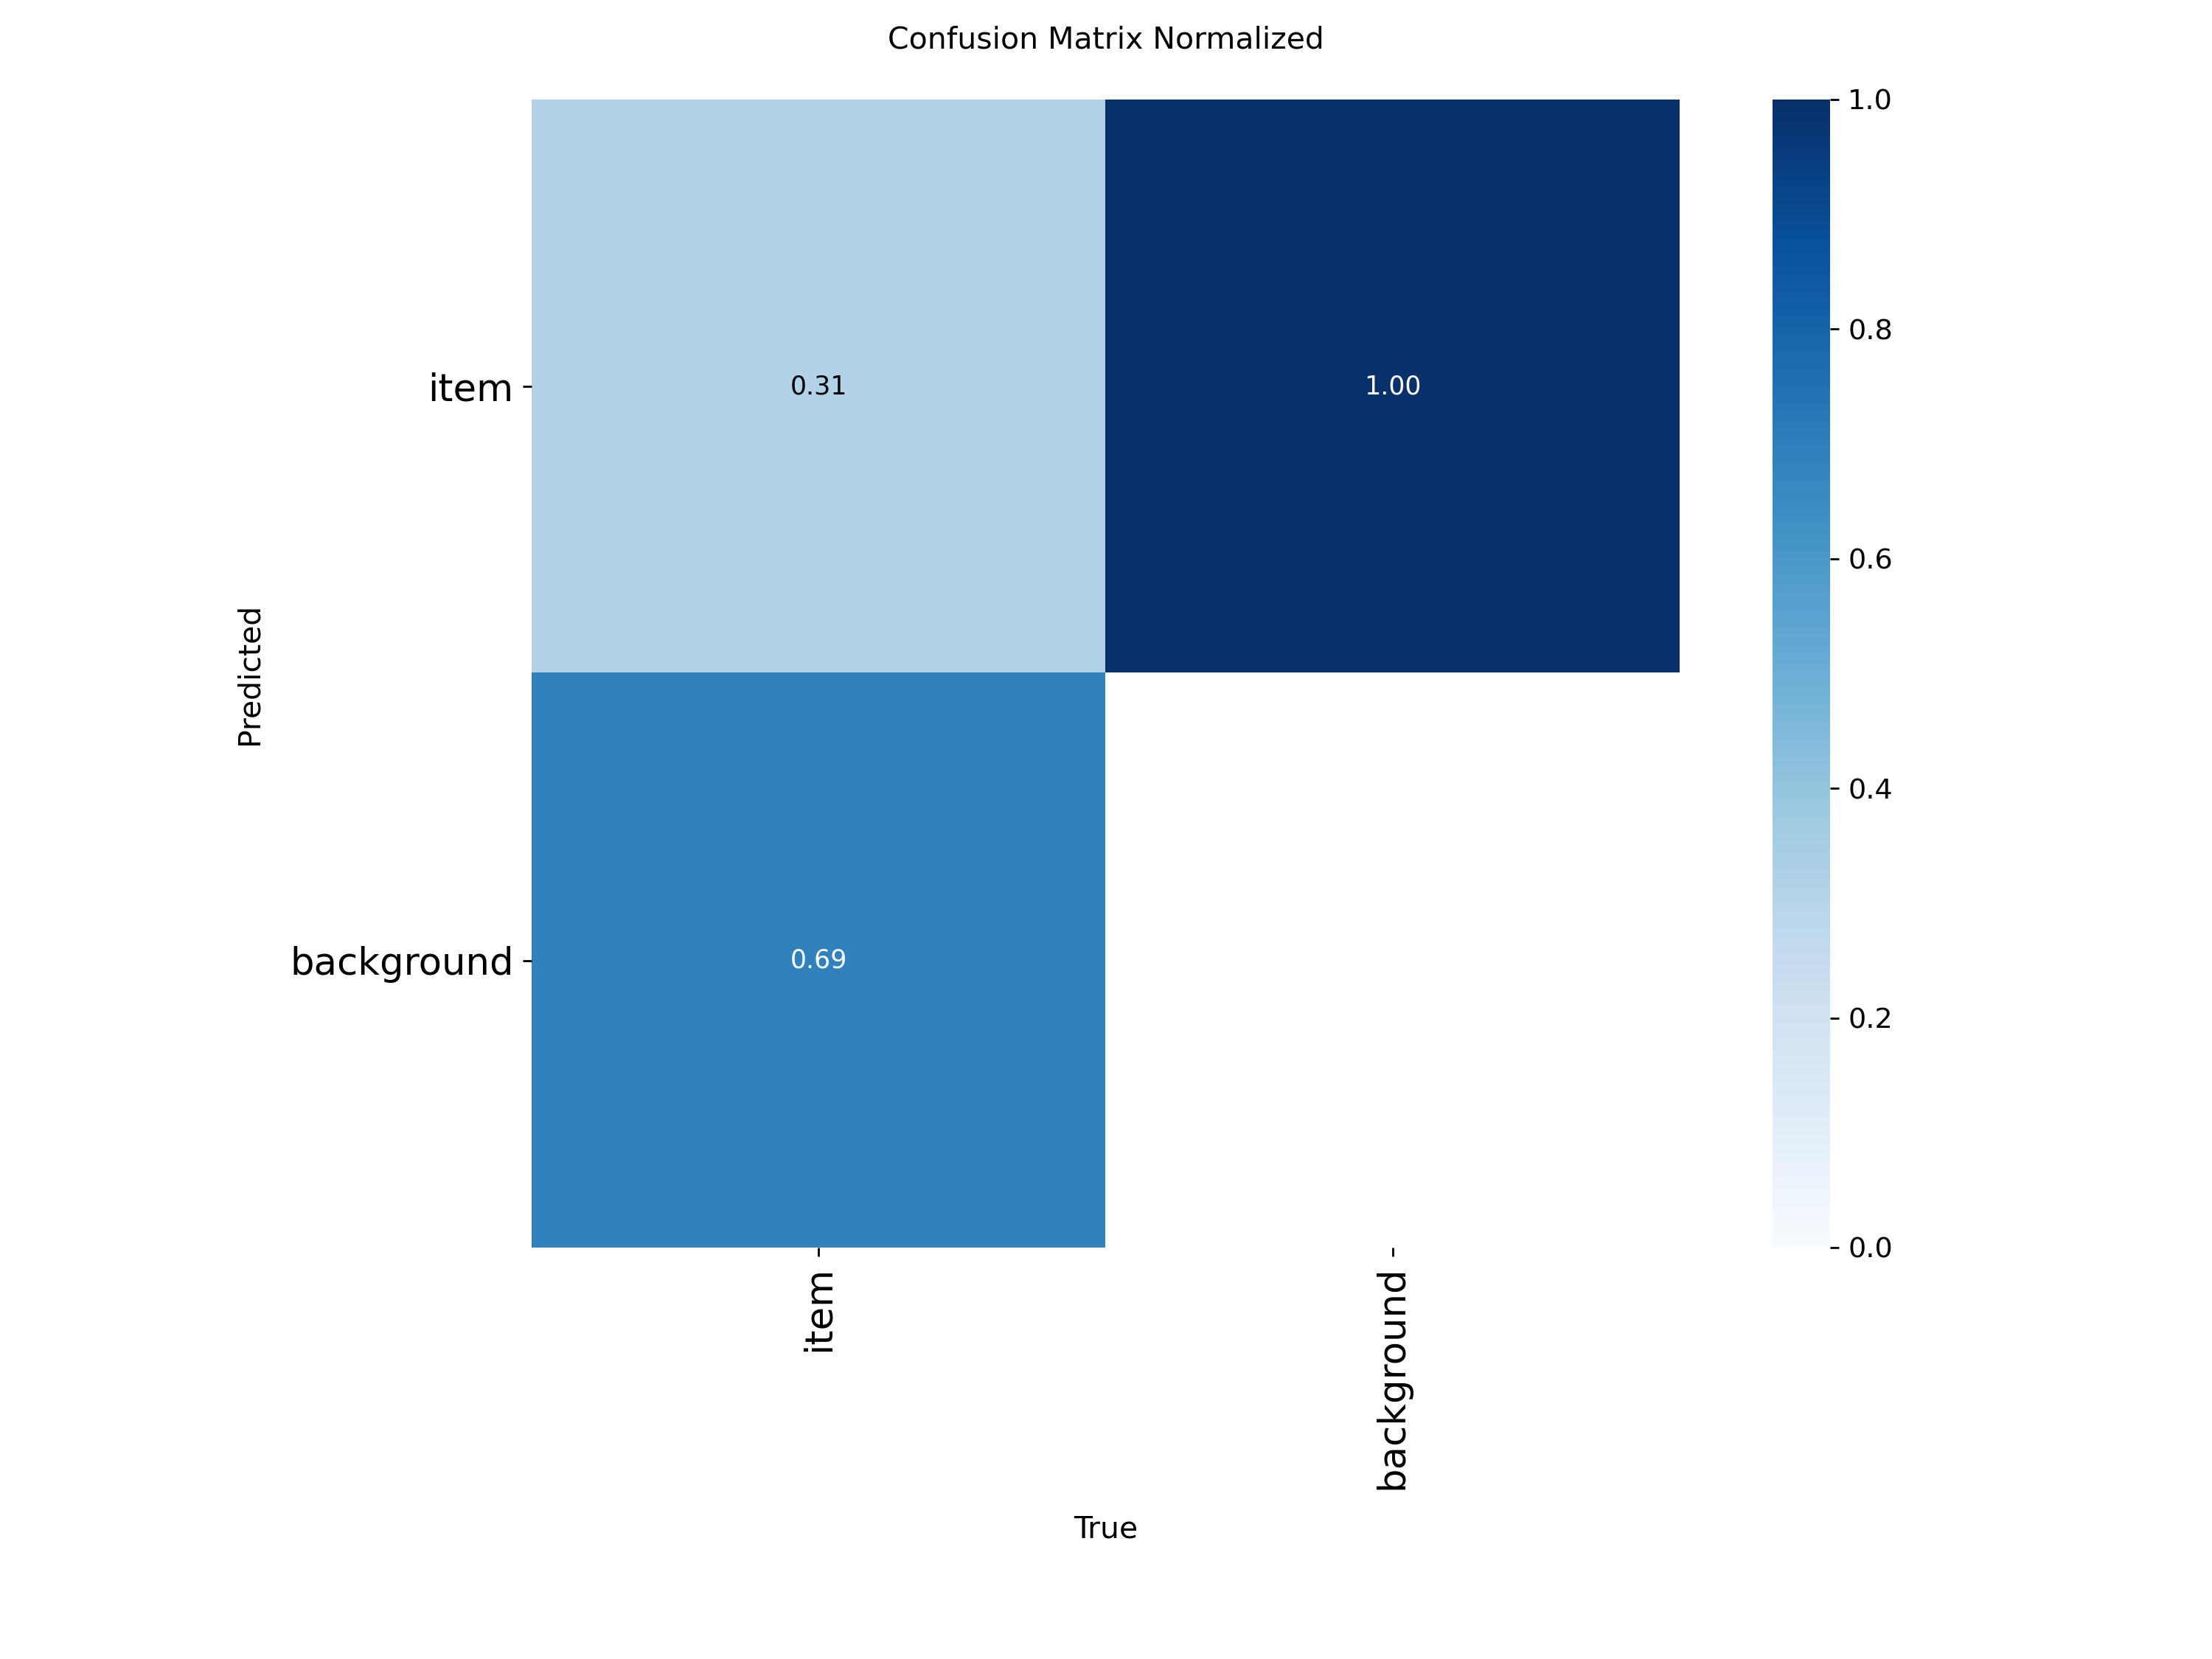

— val_batch0_pred.jpg


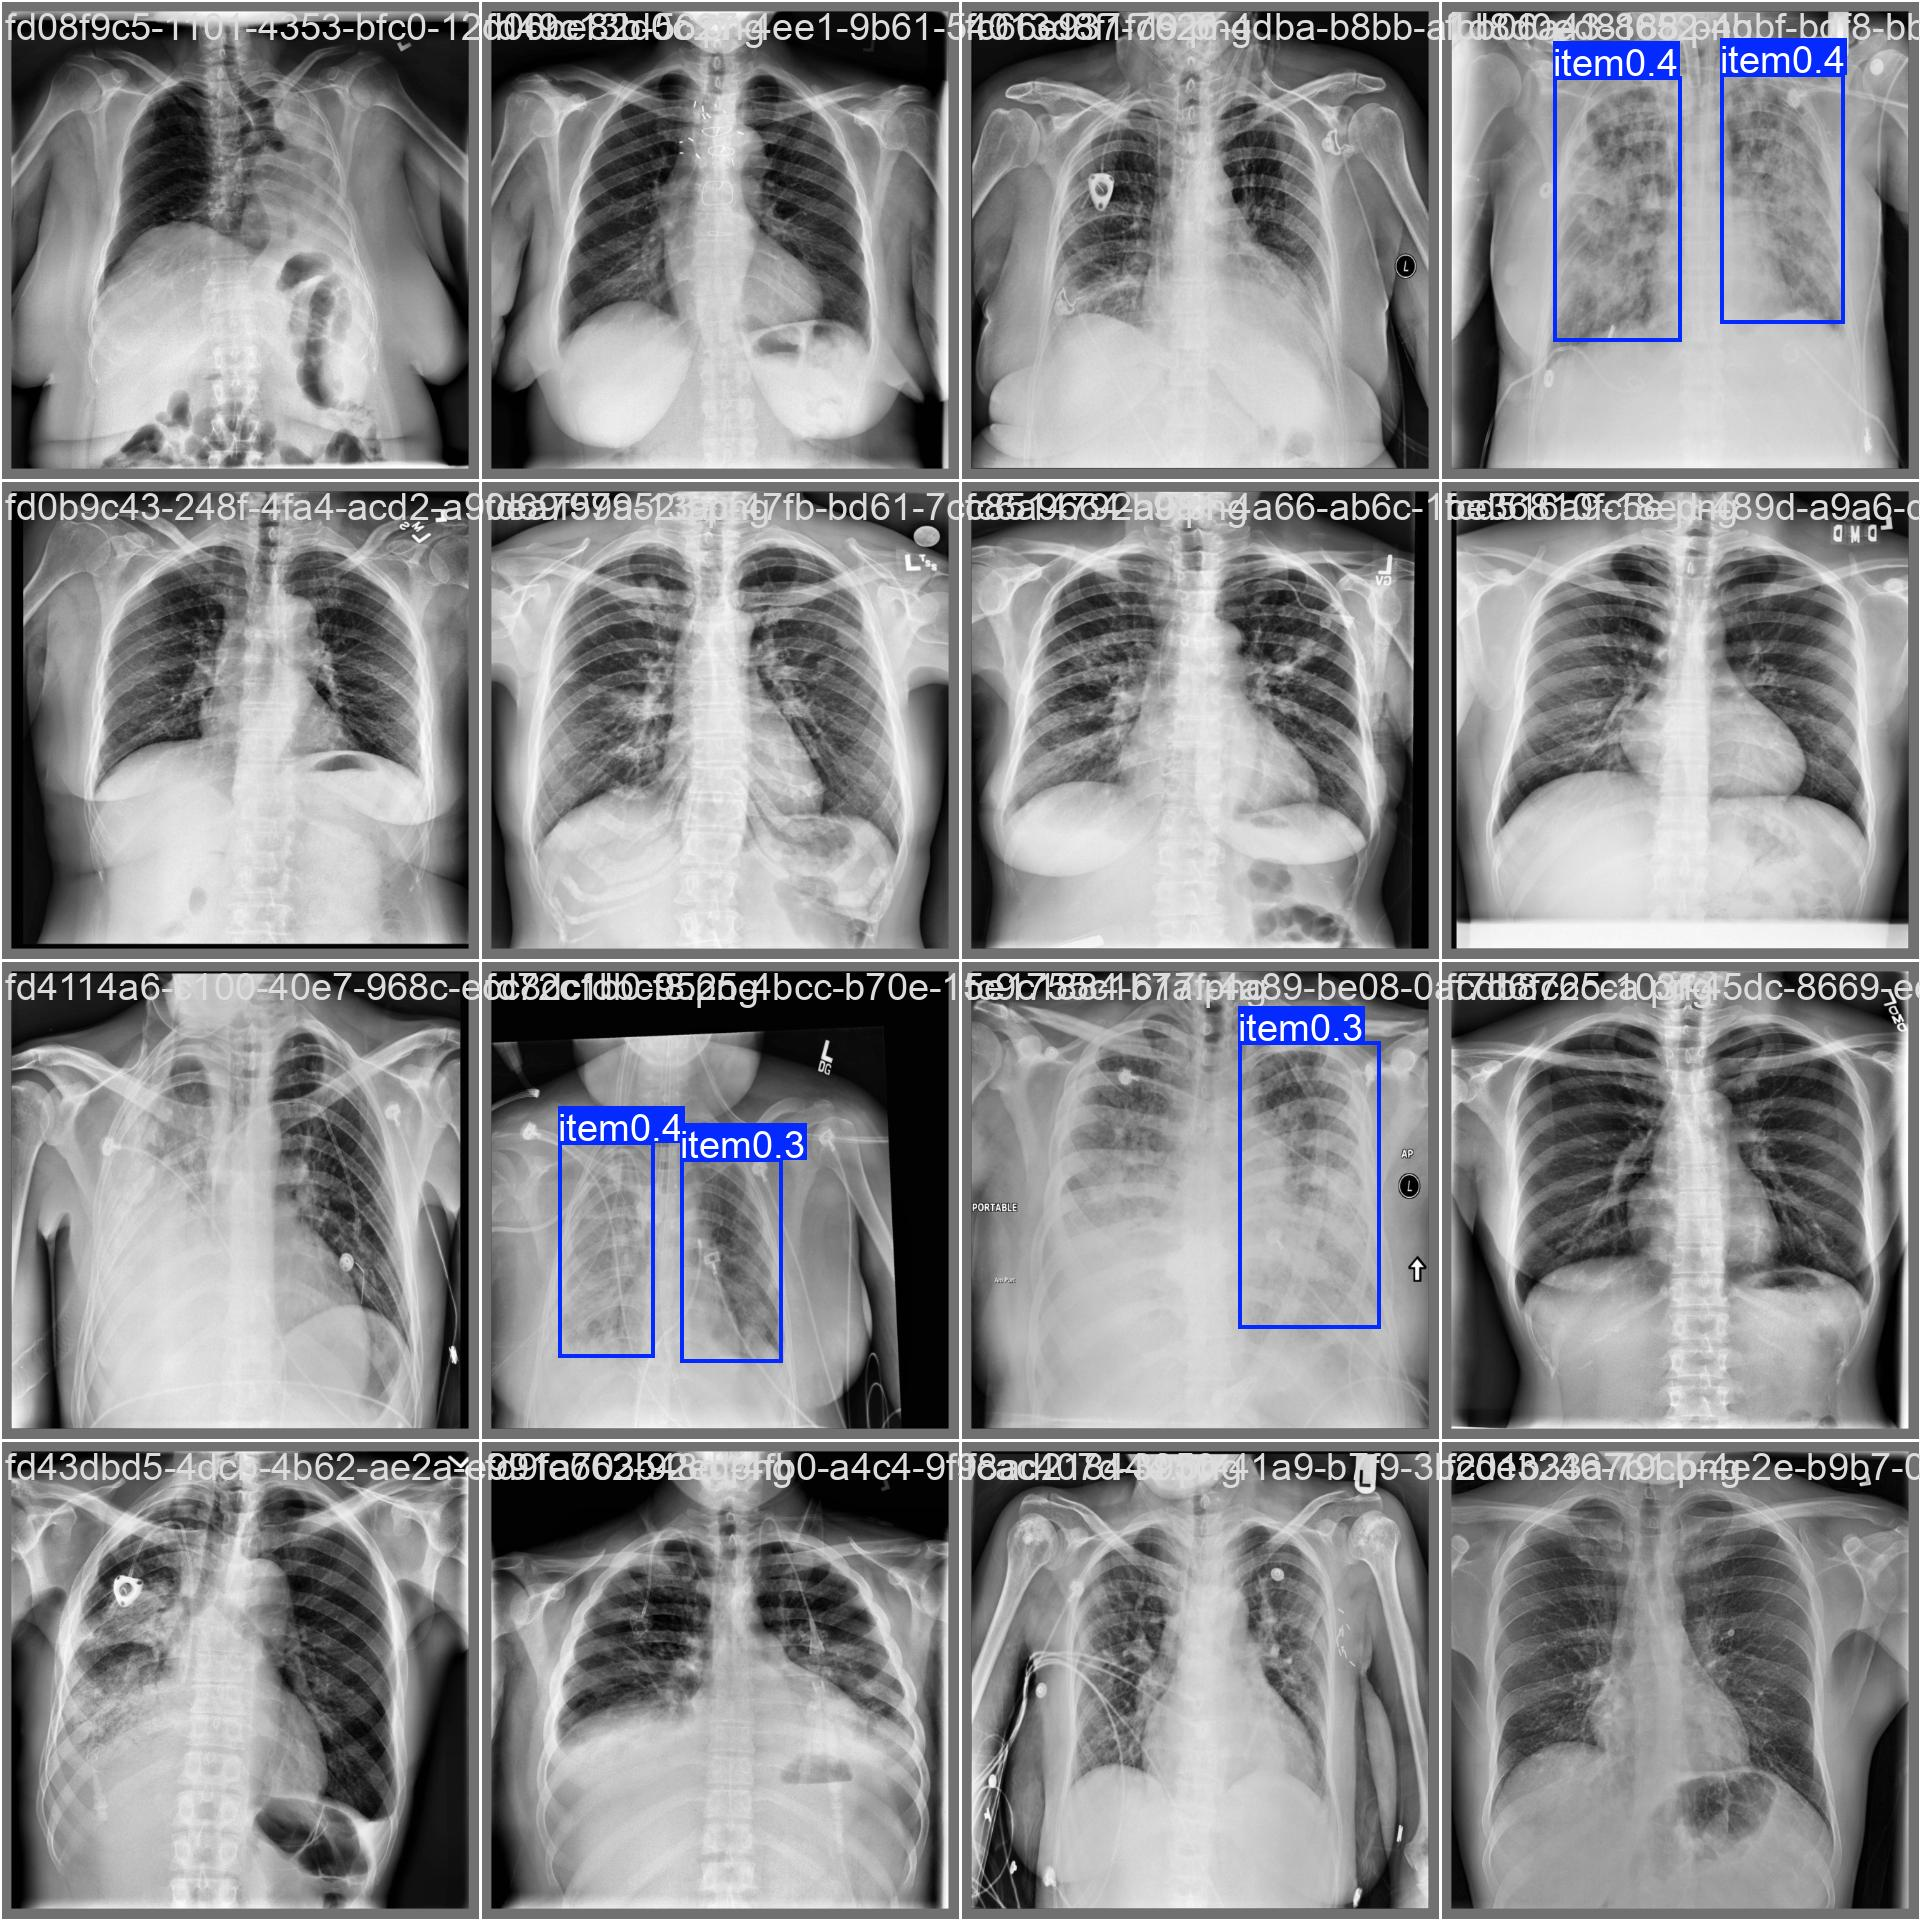

In [10]:
from IPython.display import Image as IPImage, display as dsp
for f in ['results.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png',
          'F1_curve.png', 'confusion_matrix_normalized.png', 'val_batch0_pred.jpg']:
    chemin = f'{RUN_DIR}/{f}'
    if os.path.exists(chemin):
        print('—', f); dsp(IPImage(filename=chemin, width=780))


## 7. Comparaison v2 / v3 / v4

Remplace les valeurs v2/v3 ci-dessous par tes vrais resultats si differents — pratique pour montrer une vraie demarche iterative dans la presentation.

In [11]:
v2 = {'Precision (P)': 0.4321, 'Rappel (R)': 0.5345, 'mAP@0.5': 0.3961, 'F1': 0.4778}
v3 = {'Precision (P)': 0.381,  'Rappel (R)': 0.463,  'mAP@0.5': 0.367,  'F1': round(2*0.381*0.463/(0.381+0.463+1e-9), 4)}
v4 = tableau.iloc[0].to_dict()

comparaison = pd.DataFrame([v2, v3, v4], index=[
    'v2 (ratio 1:1, 45 epochs, sans CLAHE)',
    'v3 (ratio 1:2, coupe a l\'epoch 61/100)',
    'v4 (ratio 1:1.5, CLAHE, 60 epochs)',
])
display(comparaison)


,Precision (P),Rappel (R),mAP@0.5,F1,mAP@0.5:0.95
"v2 (ratio 1:1, 45 epochs, sans CLAHE)",0.4321,0.5345,0.3961,0.4778,NaN
"v3 (ratio 1:2, coupe a l'epoch 61/100)",0.3810,0.4630,0.3670,0.4180,NaN
"v4 (ratio 1:1.5, CLAHE, 60 epochs)",0.4051,0.4498,0.4074,0.4263,0.1632


In [12]:
from IPython.display import FileLink
display(FileLink(f'{RUN_DIR}/weights/best.pt'))
display(FileLink(f'{RUN_DIR}/weights/last.pt'))
display(FileLink('/kaggle/working/metriques_finales_v4.csv'))
display(FileLink('/kaggle/working/balayage_seuil_v4.csv'))


/kaggle/working/pneumoscan_runs/pneumoscan_yolo11m_v4/weights/best.pt

/kaggle/working/pneumoscan_runs/pneumoscan_yolo11m_v4/weights/last.pt

/kaggle/working/metriques_finales_v4.csv

/kaggle/working/balayage_seuil_v4.csv

---
## Si jamais ce commit est aussi interrompu par la limite de 12h

1. Va dans **Your Work → Notebooks → cette version → Output**
2. Telecharge `weights/last.pt` (ou le dernier `epochNN.pt` grace a `save_period=5`)
3. Cree un Kaggle Dataset avec ce fichier (**Datasets → New Dataset**)
4. Dans un nouveau commit, rattache ce dataset en Input, puis :
```python
import shutil, os
os.makedirs(f'{RUN_DIR}/weights', exist_ok=True)
shutil.copy('/kaggle/input/TON-DATASET-CHECKPOINT/last.pt', f'{RUN_DIR}/weights/last.pt')
model = YOLO(f'{RUN_DIR}/weights/last.pt')
model.train(resume=True)
```